# Daily Challenge: Logistic Regression for Admission Prediction

## Objective

In this exercise, we will build a **Logistic Regression** model to predict whether a student is admitted to university based on two exam scores.

The target variable is:

- `0` = Not admitted
- `1` = Admitted

We will follow four main steps:

1. Load and explore the data.
2. Visualize admitted and non-admitted students.
3. Train a Logistic Regression model with scikit-learn.
4. Make predictions and evaluate the model using accuracy.


## 1. Import the libraries

We use:

- **pandas** to load and inspect the dataset.
- **matplotlib** to visualize the data.
- **LogisticRegression** from scikit-learn to create the classification model.
- **accuracy_score** to measure the percentage of correct predictions.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## 2. Load the dataset

The file is a text file, but its values are separated by commas, so `pd.read_csv()` can read it directly.

The dataset does not contain column names, so we add them ourselves:

- `Exam 1 Score`
- `Exam 2 Score`
- `Admitted`


In [2]:
df = pd.read_csv(
    r"/mnt/data/ex2data1.txt",
    header=None,
    names=["Exam 1 Score", "Exam 2 Score", "Admitted"]
)

df.head()

,Exam 1 Score,Exam 2 Score,Admitted
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


### Understanding the data

Each row represents one student.

The first two columns are the student's exam scores, which will be our **features (X)**.

The `Admitted` column is the result we want to predict, so it will be our **target (y)**.


In [3]:
print("Dataset shape:", df.shape)
print("\nAdmission counts:")
print(df["Admitted"].value_counts())

Dataset shape: (100, 3)

Admission counts:
Admitted
1    60
0    40
Name: count, dtype: int64


## 3. Visualize the data

We create a scatter plot to compare students who were admitted with those who were not admitted.

Each point represents one student:

- The x-axis shows the Exam 1 score.
- The y-axis shows the Exam 2 score.
- The two groups represent admitted and non-admitted students.

This visualization helps us see whether the two classes appear to be separable based on exam scores.


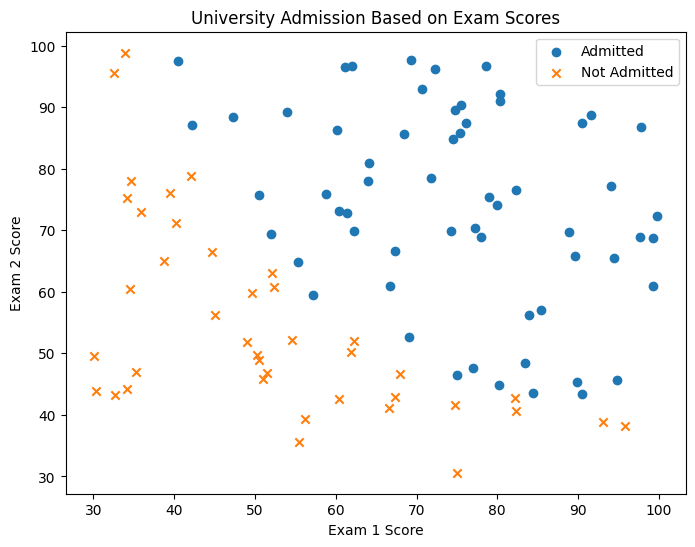

In [4]:
admitted = df[df["Admitted"] == 1]
not_admitted = df[df["Admitted"] == 0]

plt.figure(figsize=(8, 6))

plt.scatter(
    admitted["Exam 1 Score"],
    admitted["Exam 2 Score"],
    label="Admitted",
    marker="o"
)

plt.scatter(
    not_admitted["Exam 1 Score"],
    not_admitted["Exam 2 Score"],
    label="Not Admitted",
    marker="x"
)

plt.xlabel("Exam 1 Score")
plt.ylabel("Exam 2 Score")
plt.title("University Admission Based on Exam Scores")
plt.legend()
plt.show()

## 4. Define the features and the target

Machine Learning separates the dataset into:

- **X**: the input variables used to make the prediction.
- **y**: the target variable that we want the model to predict.

Here, the two exam scores are the features and admission status is the target.


In [5]:
X = df[["Exam 1 Score", "Exam 2 Score"]]
y = df["Admitted"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100, 2)
y shape: (100,)


## 5. Create and train the Logistic Regression model

Logistic Regression is a **supervised classification algorithm**.

The model learns from students whose admission result is already known. It tries to learn the relationship between their exam scores and whether they were admitted.

`model.fit(X, y)` is the training step.


In [6]:
model = LogisticRegression()

model.fit(X, y)

print("Model trained successfully.")

Model trained successfully.


## 6. Examine the model parameters

After training, the model has learned:

- an **intercept**
- one **coefficient** for each exam score

These parameters are used by Logistic Regression to calculate the probability that a student belongs to class `1` (Admitted).

A positive coefficient means that increasing that feature tends to increase the predicted probability of admission, while keeping the other feature constant.


In [7]:
print("Intercept:", model.intercept_[0])

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients

Intercept: -25.05219314312746


,Feature,Coefficient
0,Exam 1 Score,0.205355
1,Exam 2 Score,0.200584


## 7. Make predictions

Now that the model has been trained, we use `model.predict(X)`.

For each student, the model returns:

- `0` if it predicts that the student is not admitted.
- `1` if it predicts that the student is admitted.


In [8]:
y_pred = model.predict(X)

predictions = df.copy()
predictions["Predicted Admission"] = y_pred

predictions.head(10)

,Exam 1 Score,Exam 2 Score,Admitted,Predicted Admission
0,34.623660,78.024693,0,0
1,30.286711,43.894998,0,0
2,35.847409,72.902198,0,0
3,60.182599,86.308552,1,1
4,79.032736,75.344376,1,1
5,45.083277,56.316372,0,0
6,61.106665,96.511426,1,1
7,75.024746,46.554014,1,0
8,76.098787,87.420570,1,1
9,84.432820,43.533393,1,1


## 8. Calculate the accuracy

**Accuracy** is the proportion of predictions that are correct.

For example, an accuracy of `0.89` means that the model correctly classified approximately **89% of the students** in this dataset.


In [9]:
accuracy = accuracy_score(y, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Accuracy percentage:", round(accuracy * 100, 2), "%")

Accuracy: 0.89
Accuracy percentage: 89.0 %


## 9. Interpretation

The Logistic Regression model uses the two examination scores to estimate whether a student is likely to be admitted.

The model achieves an accuracy of about **89%** on this dataset, meaning that it correctly classifies most students as admitted or not admitted.

The positive coefficients for the exam scores indicate that higher exam scores are associated with a higher probability of admission.

This result shows that Logistic Regression is appropriate for this problem because the target variable has two possible classes: admitted (`1`) or not admitted (`0`).

### Important note

In this exercise, the model is trained and evaluated on the same dataset because the instructions ask us to make predictions on the dataset itself. This is useful for learning the basic workflow, but in a real Machine Learning project we would normally evaluate the model on separate unseen test data to obtain a more reliable measure of its performance.
